## Exam PGR107 Python Programming - 2026 SPRING
## Candidate number: 268
## Solo/ single candidate group.

## Task 1: Supernacci numbers.

### Task description:
The (fictional) Supernacci numbers, use slicing and the sum(list) function instead of recursion.

### Assumptions:
I assume n number starts at 1 as task defines s(1) = 1. With it I also assume we are not to handle negative numbers. That the function is for whole positive numbers.

### Method:
Stores the numbers in a list. And for each new position, (index -1) % 3 decides how many numbers are to be summed. If this turns out to be 0, last number is used instead.


In [42]:
# Task 1 - supernacci function
def supernacci(n):
    """
    Computes the supernacci number of the given n number.
    Using a list, slicing and sum().
    """
    numbers = [1]

    for index in range(2, n + 1):
        count = (index - 1) % 3

        if count == 0:
            count = 1
        numbers.append(sum(numbers[-count:]))

    return numbers[-1]


In [43]:
# Task 1 - input n for supernacci function
# I chose to limit this to 1-1000, upper bound only picked for practical reasons.
# Takes int as input so whole numbers only
n = int(input("Enter a number n: "))

if n < 1:
    print("Enter a number n >= 1: ")

elif n > 1000:
    print("Enter a number n <= 1000: ")
else:
    result = supernacci(n)
    print("For n =", n, "the supernacci number is:", result)


For n = 11 the supernacci number is: 8


In [46]:
# Task 1 - Testing & verifying the first 15 supernacci numbers
for i in range(1,16):
    print("For n =", i, "number is:", supernacci(i))

For n = 1 number is: 1
For n = 2 number is: 1
For n = 3 number is: 2
For n = 4 number is: 2
For n = 5 number is: 2
For n = 6 number is: 4
For n = 7 number is: 4
For n = 8 number is: 4
For n = 9 number is: 8
For n = 10 number is: 8
For n = 11 number is: 8
For n = 12 number is: 16
For n = 13 number is: 16
For n = 14 number is: 16
For n = 15 number is: 32


## Task 2 - 4 sided dice

### Task description:
Fixing of code for 4 sided dice.

### Assumptions:
Assumed it was ok to simplify the print statements somewhat.
I also changed variable name types from camel-case to snake, I prefer this.

### Method:
Fixed inconsistent variable name use, guesss & gues.
Sorted wrong use of random module, and wrong range for a 4 sided dice.
Sorted indentation problems, wrong use of = | ==, and lacking colon after if statement.
Simplified and made the print statements cleaner with a loop, stopping early with break on correct guess.

In [234]:
# Task 2 - fixed code
import random as rnd

dice = 0

def get_dice_guess():
    """
    Ask the user for a valid guess between 1 and 4.
    """
    guess = 0

    while guess not in [1,2,3,4]:
        guess = int(input("Guess the number on a 4-sided dice! Enter a number between 1 and 4: "))
    return guess

def roll_dice():
    """
    Rolls a 4-sided die.
    """
    return rnd.randint(1,4)

dice = roll_dice()

for attempt in range(1,5):
    guess = get_dice_guess()

    if dice == guess:
        print("Congrats! You got it!")
        break

    elif attempt < 4:
        print("Sorry! Wrong choice, try again!")
    else:
        print("Nope. You are really bad at this game.")

Sorry! Wrong choice, try again!
Sorry! Wrong choice, try again!
Sorry! Wrong choice, try again!
Congrats! You got it!


## Task 3 - Cities and points of interest

### Task description
Using two dictionaries, one with city information and one with poi information. Expand the dicts and carry out various calculations.

### Assumptions
Task says to ignore the earths curvature and use the provided simplification measurements for longitude and latitude.

### Method
First define the provided dicts and a helper function for distance calculation. Then solve the tasks in order one by one.

In [255]:
# Task 3a0 - input example dictionaries, cities & poi. Additionally helper function to calculate distance.

# Dict with name, lat/long & size of city. Added a city & poi, for testing.
cities = {
    'Bergen': [60.364098, 5.404422, 15],
    'Oslo': [59.926959, 10.779454, 10],
    'Trondheim': [63.433654, 10.390277, 5],
    'Mordor': [55.751244, 37.618423, 15]
}

# Dict with lat/long, name & grade of attraction
poi = {
    (63.426806, 10.396712): ['Nidarosdommen', 4.5],
    (59.926699, 10.701075): ['Vigelandsparken', 5],
    (59.907704, 10.753163): ['Operahuset', 4],
    (60.397561, 5.322833): ['Bryggen', 4.5],
    (60.387639, 5.321623): ['Universitetmuseet', 5],
    (60.342901, 5.336796): ['Gamlehaugen', 4],
    (55.752121, 37.617664): ['Mountdoom', 1]
}

# Set defined simplified distance for latitude and longitude
LAT_KM = 111
LONG_KM = 68

# Function to calculate distance (approximate)
def distance_km(lat1, long1, lat2, long2):
    """
    Calculates the distance in km between two sets of coordinates.
    Using simple Euclidean distance / pythagorean theorem.
    """
    lat_distance = (lat1 - lat2) * LAT_KM
    long_distance = (long1 - long2) * LONG_KM

    return (lat_distance ** 2 + long_distance ** 2) ** 0.5

def get_distance(item):
    """
    Helper function, gets the distance part of & for poi and city, reused. [name, distance] 0,1.
    """
    return item[1]


In [256]:
## Task 3a1 - Functions to find nearest city & poi

def closest_city(input_latitude, input_longitude, cities_dict):
    """
    Finds the closest cities to a given latitude and longitude.
    In the case of an equal distance between two cities, I chose to provide both with an elif and append.
    Had to also allow for some leeway here to even obtain this in testing.
    (Had envisioned this to be a far larger issue than it turned out to be).
    """
    city_distances = []

    for current_city, city_data in cities_dict.items():
        distance = distance_km(input_latitude, input_longitude, city_data[0], city_data[1])

        city_distances.append((current_city, distance)) #store city with its distance

    # get the shortest stored distance
    closest_distance =min(city_distances, key=get_distance)[1]
    result_cities = []

    for city_item  in city_distances:
        if abs(city_item[1] - closest_distance) < 1: # added 1km leeway for cities
            result_cities.append(city_item[0])

    return result_cities, closest_distance


def closest_poi(input_latitude, input_longitude, poi_dict):
    """
    Function preforms the same task as closest_city but for points of interest.
    If a tie is encountered multiple results are displayed. Made the leeway here 100m.
    To then treat close cases as approximately equally close.
    """
    poi_distances = []

    for coordinates, poi_data in poi_dict.items():
        distance = distance_km(input_latitude, input_longitude, coordinates[0], coordinates[1])

        poi_distances.append([poi_data[0], distance])

    closest_distance = min(poi_distances, key=get_distance)[1]
    result_pois = []

    for poi_item in poi_distances:
        if abs(poi_item[1] - closest_distance) < 0.1: # 100 meters leeway for point of interests
            result_pois.append(poi_item[0])

    return result_pois, closest_distance

In [257]:
## Task 3a2 -  Block for user input of latitude & longitude

latitude = float(input("Enter a latitude: "))
longitude = float(input("Enter a longitude: "))

closest_cities, city_distance = closest_city(latitude, longitude, cities)
closest_pois, poi_distance = closest_poi(latitude, longitude, poi)

if len(closest_cities) == 1:
    print("The closest city is:", closest_cities[0], ", distance is: ", round(city_distance, 2), "km")
else:
    print("Closest cities:")
    for city in closest_cities:
        print(city, ", distance with 1km margin is approximately:", round(city_distance, 2), "km")

if len(closest_pois) == 1:
    print("The closest poi is:", closest_pois[0], ", distance is: ", round(poi_distance, 2), "km")
else:
    print("Closest pois:")
    for poi_name in closest_pois:
        print(poi_name, ", distance with 100m margin is approximately:", round(poi_distance, 2), "km")

The closest city is: Oslo , distance is:  82.15 km
The closest poi is: Vigelandsparken , distance is:  79.62 km


In [258]:
## Task 3b - Compute city boundaries

def create_city_boundaries(cities_dict):
    """
    Computes boundaries and adds north, south, east & west boundaries to cities_dict.
    Simplified, treating the city as a square around the city center. Converting city size to lat/ long
    degree adjustments and using this to calculate the borders.
    """
    for city_name, city_data in cities_dict.items():
        latitude = city_data[0]
        longitude = city_data[1]
        city_size = city_data[2]

        lat_adjustment = city_size / LAT_KM
        long_adjustment = city_size / LONG_KM

        north = latitude + lat_adjustment
        south = latitude - lat_adjustment
        east = longitude + long_adjustment
        west = longitude - long_adjustment

        # Altered from .extending to [3:] = [] so on reruns replacing data if borders are already there
        city_data[3:] = [north, south, east, west] # Otherwise would grow and grow

create_city_boundaries(cities)

for city_name, city_data in cities.items():
    print(city_name,"city borders:")
    print("North latitude:", city_data[3])
    print("South latitude:", city_data[4])
    print("East longitude:", city_data[5])
    print("West longitude:", city_data[6])
    print()

Bergen city borders:
North latitude: 60.499233135135135
South latitude: 60.22896286486486
East longitude: 5.625010235294118
West longitude: 5.1838337647058825

Oslo city borders:
North latitude: 60.01704909009009
South latitude: 59.8368689099099
East longitude: 10.92651282352941
West longitude: 10.632395176470588

Trondheim city borders:
North latitude: 63.47869904504504
South latitude: 63.388608954954954
East longitude: 10.463806411764706
West longitude: 10.316747588235293

Mordor city borders:
North latitude: 55.88637913513514
South latitude: 55.61610886486486
East longitude: 37.839011235294116
West longitude: 37.397834764705884



In [259]:
## Task 3c - Assign POIs to cities

def assign_pois(cities_dict, poi_dict):
    """
    Checks what POIs are located within a cities boundaries. Using the north, south, east
    and west boundaries added to cities_dict in 3b. If poi is found within the borders of a city
    it then appends this to the city.
    """
    city_pois = {}

    for city_name, city_data in cities_dict.items():
        north = city_data[3]
        south = city_data[4]
        east = city_data[5]
        west = city_data[6]
        city_pois[city_name] = []

        for coordinates, poi_data in poi_dict.items():
            poi_latitude = coordinates[0]
            poi_longitude = coordinates[1]
            poi_name = poi_data[0]

            # Verify if poi is inside city borders
            within_latitude = south <= poi_latitude <= north
            within_longitude = west <= poi_longitude <= east

            if within_latitude and within_longitude:
                city_pois[city_name].append(poi_name)

    return city_pois

pois_in_cities = assign_pois(cities, poi) # Saved and used for 3d
print(pois_in_cities)

{'Bergen': ['Bryggen', 'Universitetmuseet', 'Gamlehaugen'], 'Oslo': ['Vigelandsparken', 'Operahuset'], 'Trondheim': ['Nidarosdommen'], 'Mordor': ['Mountdoom']}


In [260]:
## Task 3d - Compute average POI rating per city

def average_poi_scores(pois_in_cities, poi_dict):
    """
    Computes the average score of all POIs within each city.
    Uses the saved pois_in_cities from task 3c.
    """
    city_average_score = {}

    for city_name, poi_names in pois_in_cities.items():
        rated_pois = []

        # check score of each poi assigned to a city
        for poi_name in poi_names:
            for poi_data in poi_dict.values():
                if poi_data[0] == poi_name:
                    rated_pois.append(poi_data[1])

        if rated_pois:
            city_average_score[city_name] = sum(rated_pois) / len(rated_pois)
        else:
            city_average_score[city_name] = "No rated POIs found"

    return city_average_score

average_score = average_poi_scores(pois_in_cities, poi)
print(average_score)


{'Bergen': 4.5, 'Oslo': 4.5, 'Trondheim': 4.5, 'Mordor': 1.0}


In [261]:
## Task 3e - Create a list of ordered POIs by distance from the city center, from nearest to farthest.

def order_pois_by_distance(cities_dict, poi_dict, pois_in_cities):
    """
    Creates a list of POI names for each city, ordered by distance to city center. Nearest to farthest.
    """
    ordered_city_pois = {}

    for city_name, poi_names in pois_in_cities.items():
        city_data = cities_dict[city_name]
        city_latitude = city_data[0]
        city_longitude = city_data[1]

        poi_distances = []

        for poi_name in poi_names:
            for coordinates, poi_data in poi_dict.items():
                if poi_data[0] == poi_name:
                    distance = distance_km(city_latitude, city_longitude, coordinates[0], coordinates[1])
                    poi_distances.append([poi_name, distance]) #stores poi name with distance to cc

        poi_distances.sort(key=get_distance) # sort by distance
        ordered_city_pois[city_name] = [] # creates the final list for a city

        for poi_item in poi_distances:
            ordered_city_pois[city_name].append(poi_item[0]) # adds pois in order into the list

    return ordered_city_pois

ordered_pois = order_pois_by_distance(cities, poi, pois_in_cities)

print(ordered_pois)


{'Bergen': ['Gamlehaugen', 'Universitetmuseet', 'Bryggen'], 'Oslo': ['Operahuset', 'Vigelandsparken'], 'Trondheim': ['Nidarosdommen'], 'Mordor': ['Mountdoom']}


### Task 3e - Result discussion.
Was a little confused here with my results here for Bergen, im no local but still it did not agree
with my geographical understanding, seemed reversed.
Yet the function could not possibly work correctly for one city and not the other.
So looked into the provided coordinates for Bergen and found the culprit, seems an inland mountain
is provided as the city center. With that it made perfect sense.

### Task 4 - implementing a trace function

### Assumptions:
I assume it is the first diagonal so from the first corner starting at top left.
### Method:
Checks if rows = columns using .shape for numpy 2d array (rows,columns) 0,1, and sums the diagonal.
Lastly tested with 3 numpy arrays, 3x3, 4x4 and a 3x4 error example.

In [225]:
# Task 4 - Trace A function

import numpy as np

def trace(A):
    """
    Checks if the matrix, rank 2 numPy array, is a square.
    If so the trace function sums the first diagonal (from top left to bottom right).
    """
    rows = A.shape[0]
    cols = A.shape[1]

    if rows != cols:
        print("Matrix is not square.")
    else:
        diagonal_sum = 0

        for i in range(rows):
            diagonal_sum += A[i][i]

        print("Trace:", diagonal_sum)

A = np.array([[4, 6, 9],
              [9, 3, 5],
              [7, 2, 8]])
trace(A)

B = np.array([[ 1, 2, 3 ,4],
              [ 5, 6, 7, 8],
              [ 9, 10, 11, 12],
              [13, 14, 15, 16]])
trace(B)

C = np.array([[ 1, 2, 3 ,4],
              [ 5, 6, 7, 8],
              [ 9, 10, 11, 12]])
trace(C)

Trace: 15
Trace: 34
Matrix is not square.


### Task 5 - Open task, use case study

### Assumptions:
I went with the provided example task, (tried to keep to this) as I do have an oral examination in quantum
pgr coming up, I was a bit curious to find out If I had any potential advantage here.

Selected subjects that had dual codes for both oral and written examinations

## Method:

First, loaded and cleaned the Oslo CSV file using pandas. Shortened long column names, converted grade
averages & student counts to numeric values. And filtered the data.

Secondly explored the 2024-2025 data with visualizations. Made some observations, comments and insight.

Lastly, I checked Oslo data with the same method as the article. And compared Troms region data to see if the
same pattern between standpunkt - examinations; pervailed and matched in an entierly differnt region of the
country. And added some comments to try and rationalize my results.



In [227]:
# Task 5.1 - CSV load file, inspect & order data
import pandas as pd
import matplotlib.pyplot as plt

CSV_1 = "CSV_1.csv"

df = pd.read_csv(CSV_1, sep="\t", encoding="utf-16le", skiprows=1)

df.head()

df.columns

Index(['FagNivaa', 'EnhetNivaa', 'Vurderingsfagkode', 'Nasjonaltkode',
       'Fylkekode', 'Organisasjonsnummer', 'Vurderingsfagnavn', 'Nasjonalt',
       'Fylke', 'EnhetNavn',
       '2024-25.Muntlig eksamen.Alle eierformer.Alle kjønn.Snittkarakter',
       '2024-25.Muntlig eksamen.Alle eierformer.Alle kjønn.Antall elever',
       '2024-25.Skriftlig eksamen.Alle eierformer.Alle kjønn.Snittkarakter',
       '2024-25.Skriftlig eksamen.Alle eierformer.Alle kjønn.Antall elever',
       '2024-25.Standpunkt.Alle eierformer.Alle kjønn.Snittkarakter',
       '2024-25.Standpunkt.Alle eierformer.Alle kjønn.Antall elever'],
      dtype='str')

In [228]:
# 5.1 - Changing and compacting column names for ease of use.

df = df.rename(columns={'2024-25.Muntlig eksamen.Alle eierformer.Alle kjønn.Snittkarakter': 'oral_average',
       '2024-25.Muntlig eksamen.Alle eierformer.Alle kjønn.Antall elever': 'oral_number',
       '2024-25.Skriftlig eksamen.Alle eierformer.Alle kjønn.Snittkarakter':'written_average',
       '2024-25.Skriftlig eksamen.Alle eierformer.Alle kjønn.Antall elever': 'written_number',
       '2024-25.Standpunkt.Alle eierformer.Alle kjønn.Snittkarakter': 'standpunkt_average',
       '2024-25.Standpunkt.Alle eierformer.Alle kjønn.Antall elever': 'standpunkt_number',})

# Think I will just keep to the use of "standpunkt_" here. Final subject grade / total / surmised / final grade; all seem "off" to use.

df.dtypes

FagNivaa               int64
EnhetNivaa             int64
Vurderingsfagkode        str
Nasjonaltkode            str
Fylkekode              int64
Organisasjonsnummer      str
Vurderingsfagnavn        str
Nasjonalt                str
Fylke                    str
EnhetNavn                str
oral_average             str
oral_number              str
written_average          str
written_number           str
standpunkt_average       str
standpunkt_number        str
dtype: object

In [229]:
# 5.1 - Changing data types from str to numeric float

average_columns = ["oral_average", "written_average", "standpunkt_average"]

for column in average_columns:
    df[column] = df[column].str.replace(",", ".")
    df[column] = pd.to_numeric(df[column], errors="coerce")

number_columns = ["oral_number", "written_number", "standpunkt_number"]

for column in number_columns:
    df[column] = df[column].astype(str).str.replace(" ", "")
    df[column] = pd.to_numeric(df[column], errors="coerce")

df.dtypes

FagNivaa                 int64
EnhetNivaa               int64
Vurderingsfagkode          str
Nasjonaltkode              str
Fylkekode                int64
Organisasjonsnummer        str
Vurderingsfagnavn          str
Nasjonalt                  str
Fylke                      str
EnhetNavn                  str
oral_average           float64
oral_number            float64
written_average        float64
written_number         float64
standpunkt_average     float64
standpunkt_number      float64
dtype: object

In [230]:
# 5.1 - Checking & verifying
df[average_columns + number_columns].describe()
# Can already see here there is discrepancy in the average grades of "oral"- "written" - "standpunkt"
# But my max number of students seem too high, will have to remove the national average.

,oral_average,written_average,standpunkt_average,oral_number,written_number,standpunkt_number
count,67.000000,74.000000,164.000000,67.00000,74.000000,164.000000
mean,4.234328,3.455405,3.967073,265.80597,1222.040541,2111.457317
std,0.674773,0.622003,0.608035,1084.25467,5264.394340,6943.564912
min,1.900000,2.000000,2.600000,6.00000,6.000000,10.000000
25%,3.850000,3.100000,3.500000,8.00000,15.000000,65.000000
50%,4.200000,3.500000,4.000000,31.00000,83.000000,116.000000
75%,4.700000,3.900000,4.400000,57.50000,208.500000,193.750000
max,5.500000,4.800000,5.500000,6325.00000,32205.000000,32500.000000


In [231]:
# 5.1 - Checking & verifying
df["Fylke"].value_counts()

Fylke
Oslo           204
Alle fylker     20
Name: count, dtype: int64

In [232]:
# 5.1 Filtering out the national average

# All oslo schools filtered to the individual school level, might be of use to take a deep dive.
oslo_schools = df[(df["Fylke"] == "Oslo") & (df["EnhetNivaa"] == 3)]

# Likely of more use for me, Oslo schools in total.
oslo_total = df[(df["Fylke"] == "Oslo") & (df["EnhetNivaa"] == 2)]

# oslo_schools.shape

oslo_schools[["EnhetNivaa", "Fylke", "EnhetNavn", "Vurderingsfagkode", "Vurderingsfagnavn"]].head()

,EnhetNivaa,Fylke,EnhetNavn,Vurderingsfagkode,Vurderingsfagnavn
3,3,Oslo,Akademiet Norsk restaurantskole Sti,ENG1009,Engelsk vg1 yrkesfaglige utdanningsprogram
4,3,Oslo,Akademiet Oslo AS,ENG1009,Engelsk vg1 yrkesfaglige utdanningsprogram
5,3,Oslo,Bjørnholt videregående skole,ENG1009,Engelsk vg1 yrkesfaglige utdanningsprogram
6,3,Oslo,Edvard Munch videregående skole,ENG1009,Engelsk vg1 yrkesfaglige utdanningsprogram
7,3,Oslo,Eikelund videregående skole,ENG1009,Engelsk vg1 yrkesfaglige utdanningsprogram


In [233]:
# 5.1 - Verifying
oslo_total[["oral_average", "written_average", "standpunkt_average", "oral_number", "written_number", "standpunkt_number"]].describe()

# Seems better now, participant numbers seem accurate. Discrepancy has shrunk somewhat, but is still there.

,oral_average,written_average,standpunkt_average,oral_number,written_number,standpunkt_number
count,5.000000,5.000000,6.000000,5.000000,5.000000,6.000000
mean,4.060000,3.340000,3.983333,262.200000,1101.000000,3044.666667
std,0.517687,0.497996,0.411906,461.812408,2194.816052,1752.501488
min,3.300000,2.500000,3.500000,43.000000,94.000000,1063.000000
25%,3.900000,3.300000,3.750000,44.000000,105.000000,1713.500000
50%,4.100000,3.500000,3.950000,63.000000,126.000000,2775.500000
75%,4.300000,3.700000,4.075000,73.000000,153.000000,4570.250000
max,4.700000,3.700000,4.700000,1088.000000,5027.000000,5126.000000


## 5.1 On selection of Subjects
As I wanted to solve the given example in 5.3 I limited my subject selections to the following:

Norwegian "yrkesfaglig": NOR1262: written, NOR 1263: oral

Norwegian "general": NOR1267: written, NOR 1269: oral

English "yrkesfaglig": ENG 1009: written, ENG 1010: oral

Mathematics 1P: MAT1019: written, MAT1020: oral

Mathematics 1T: MAT1021: written, MAT1022: oral

Reasoning for my choices of subjects:
I picked these 5 oral and 5 written examinations as they rather than 10 subjects really are 5 subjects.
Underlying reasoning with this is I seek to not end up comparing apples to oranges.
Most subjects here have both an oral and written examination component as a given.
And so are taught with this in mind.
The exception, the case of NOR1267/1269 is taught with the expectation of a potential oral examination.
These will therefore be an excellent tool for me in 5.3, to there look for discrepancies between standpunkt, oral and written examinations. And I think the most logical way to accurately seek such discrepancies out.

As for assessment types I naturally included all as I wanted to look into the differences between standpunkt - oral and written.

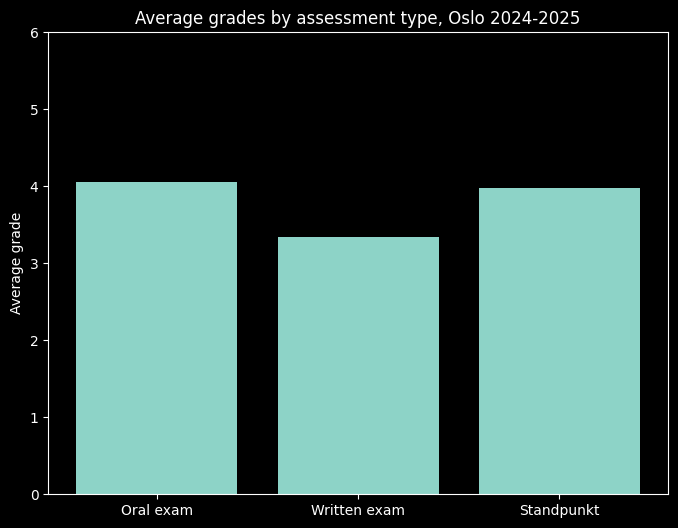

In [191]:
# Task 5.2 - Visualization & explanation of data.

assessment_averages = {
    "Oral exam": oslo_total["oral_average"].mean(),
    "Written exam": oslo_total["written_average"].mean(),
    "Standpunkt": oslo_total["standpunkt_average"].mean(),
}

plt.figure(figsize=(8, 6))
plt.bar(assessment_averages.keys(), assessment_averages.values())
plt.title("Average grades by assessment type, Oslo 2024-2025")
plt.ylabel("Average grade")
plt.ylim(0, 6)
plt.show()

# Do notice a marked effect, with written exams having significantly lower results.
# Whereas Oral exams in my data are slightly ahead of standpunkt / final grade.

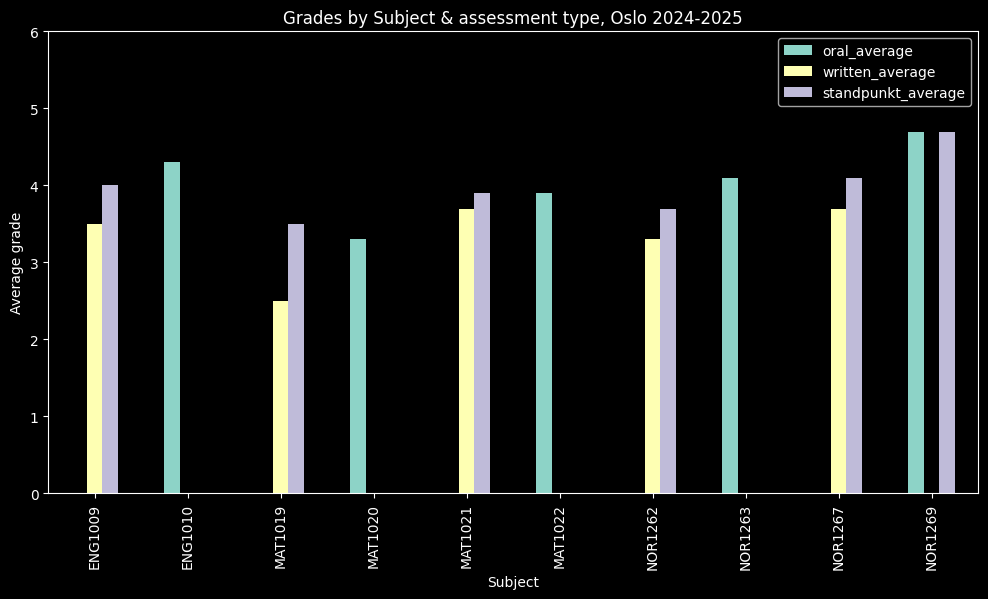

In [195]:
# Task 5.2 - Visualization by subject

subject_plot = oslo_total[["Vurderingsfagkode", "oral_average", "written_average", "standpunkt_average"]].copy()

subject_plot = subject_plot.set_index("Vurderingsfagkode")
subject_plot.plot(kind="bar", figsize=(12, 6))
plt.title("Grades by Subject & assessment type, Oslo 2024-2025")
plt.ylabel("Average grade")
plt.ylim(0, 6)
plt.show()

## Looking into the chosen data by subject.
Some outliers here: the lowest grade on average MAT1019/1020 or "P math" actually comes out with a higher avg standpunkt than both its oral and written examinations! Would not think that to be possible.
Have not had this subject myself, I am ancient, from before the reform to P/Y math.
Suspect more goes into this grade than just the exams, mid term tests and similar graded work.
That or possibly I have found that math teachers are nice. But that cannot be. No no this is impossible :-)

The worst offenders from my chosen data seems to be the languages.
My wholly subjective understanding here, is that this to a degree is reasonable.
As in my view it is easier to speak English or Norwegian, than to master writing (grammatical correctness).
Aided by the fact we do not do voiceovers for movies and tv shows (beyond kids shows), so some use of the languages is to be expected. Then I also find it is not the case that everyone is an aspiring writer.

Standard theoretical T1 math (MAT1021/MAT/1022) appears to be the least problematic & the fairest graded of the selection.

Overall the data supports that written exams tend to be lower than standpunkt, while oral examinations are
 often higher than standpunkt; or close to this final grade.

## Task 5.3 - Problem definition

The problem I seek to investiage is:

Do written exam grades tend to be lower than standpunkt grades, and do oral (or oral-practical) exam grades
tend to be closer to or higher than the standpunkt grades?

I first look for this pattern in Oslo. Shifts over time I gauged less relevant for my problem, therefore I
instead compare Oslo with Tromso to find out if this pattern is still detectable or present on the other side of the country.

### Hypothesis

My hypothesis is that written exam grades is generally lower than standpunkt grades, while oral/ oral-practical grades are closer to or higher than standpunkt grades.

In [242]:
# Task 5.3 - Loading and preparation of the Tromso data (same subjects & options).

CSV_2 = "CSV_2.csv"

tromso_df = pd.read_csv(CSV_2, sep="\t", encoding="utf-16le", skiprows=1)

tromso_df = tromso_df.rename(columns={
    '2024-25.Muntlig eksamen.Alle eierformer.Alle kjønn.Snittkarakter': 'oral_average',
    '2024-25.Muntlig eksamen.Alle eierformer.Alle kjønn.Antall elever': 'oral_number',
    '2024-25.Skriftlig eksamen.Alle eierformer.Alle kjønn.Snittkarakter':'written_average',
    '2024-25.Skriftlig eksamen.Alle eierformer.Alle kjønn.Antall elever': 'written_number',
    '2024-25.Standpunkt.Alle eierformer.Alle kjønn.Snittkarakter': 'standpunkt_average',
    '2024-25.Standpunkt.Alle eierformer.Alle kjønn.Antall elever': 'standpunkt_number'
})

average_columns = ["oral_average", "written_average", "standpunkt_average"]

for column in average_columns:
    tromso_df[column] = tromso_df[column].str.replace(",", ".")
    tromso_df[column] = pd.to_numeric(tromso_df[column], errors="coerce")

number_columns = ["oral_number", "written_number", "standpunkt_number"]

for column in number_columns:
    tromso_df[column] = tromso_df[column].astype(str).str.replace(" ", "")
    tromso_df[column] = pd.to_numeric(tromso_df[column], errors="coerce")

# The tromso data needed a trailing space here at the end of "Troms - Romsa - Tromssa "
tromso_total = tromso_df[(tromso_df["Fylke"] == "Troms - Romsa - Tromssa ") & (tromso_df["EnhetNivaa"] == 2)]

tromso_total[["Vurderingsfagkode", "Vurderingsfagnavn",
              "oral_average", "written_average", "standpunkt_average"]]

# The Troms dataset contains the selected subject codes, but not all of them have visible values at the county level. But still use able to compare written exam result (-) standpunkt.

,Vurderingsfagkode,Vurderingsfagnavn,oral_average,written_average,standpunkt_average
2,ENG1009,Engelsk vg1 yrkesfaglige utdanningsprogram,NaN,3.1,4.0
18,MAT1019,Matematikk 1P,NaN,2.5,3.5
37,MAT1021,Matematikk 1T,NaN,3.1,4.0
56,NOR1262,"Norsk, vg2 yrkesfaglige utdanningsprogram",NaN,3.4,4.0
72,NOR1267,"Norsk hovedmål, vg3 studieforberedende utdanni...",NaN,3.7,4.2
88,NOR1269,"Norsk, vg3 studieforberedende utdanningsprogra...",4.5,NaN,4.6


In [243]:
# Task 5.3 - grade gap columns for tromso and oslo

oslo_total = oslo_total.copy()
tromso_total = tromso_total.copy()

oslo_total["region"] = "Oslo"
tromso_total["region"] = "Troms"

#Oral gap turned out to be a bit of a waste, but I already knew this would be the case.
oslo_total["written_gap"] = oslo_total["written_average"] - oslo_total["standpunkt_average"]
oslo_total["oral_gap"] = oslo_total["oral_average"] - oslo_total["standpunkt_average"]

tromso_total["written_gap"] = tromso_total["written_average"] - tromso_total["standpunkt_average"]
tromso_total["oral_gap"] = tromso_total["oral_average"] - tromso_total["standpunkt_average"]

comparison_data = pd.concat([oslo_total, tromso_total])

comparison_data[[
    "region",
    "Vurderingsfagkode",
    "written_gap",
    "oral_gap"
]]


,region,Vurderingsfagkode,written_gap,oral_gap
2,Oslo,ENG1009,-0.5,NaN
22,Oslo,ENG1010,NaN,NaN
35,Oslo,MAT1019,-1.0,NaN
70,Oslo,MAT1020,NaN,NaN
83,Oslo,MAT1021,-0.2,NaN
117,Oslo,MAT1022,NaN,NaN
128,Oslo,NOR1262,-0.4,NaN
148,Oslo,NOR1263,NaN,NaN
156,Oslo,NOR1267,-0.4,NaN
191,Oslo,NOR1269,NaN,0.0


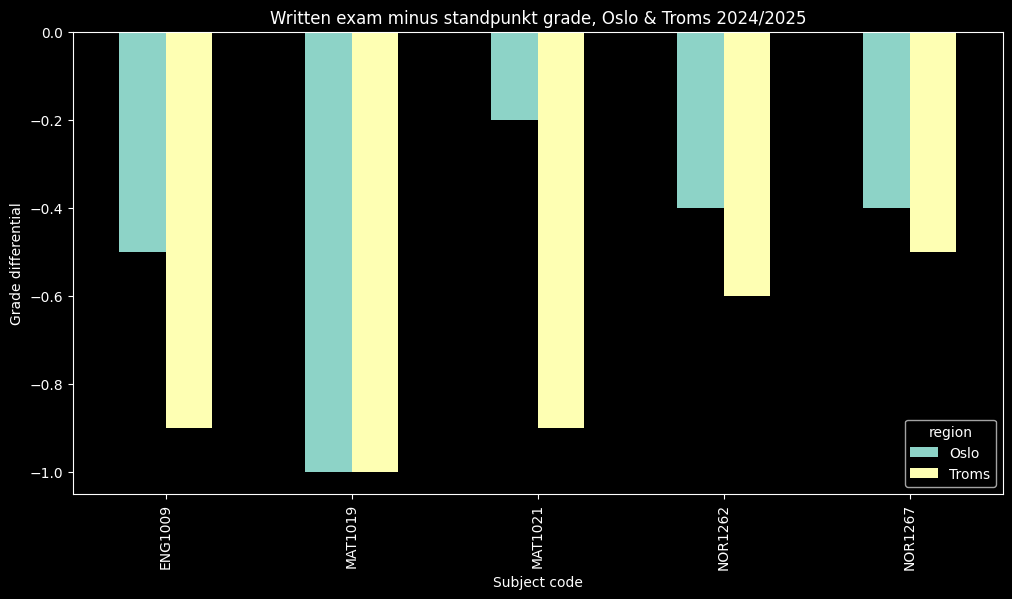

In [254]:
# Task 5.3 - Visualization of written exam gap

written_gap_plot = comparison_data[[
    "region",
    "Vurderingsfagkode",
    "written_gap",
]].dropna()

written_gap_plot = written_gap_plot.pivot(
    index="Vurderingsfagkode",
    columns="region",
    values="written_gap")

written_gap_plot.plot(kind="bar", figsize=(12, 6))
plt.title("Written exam minus standpunkt grade, Oslo & Troms 2024/2025")
plt.ylabel("Grade differential")
plt.xlabel("Subject code")
plt.show()

In [248]:
# Task 5.3 - Oslo average written exam minus standpunkt by school

oslo_school_gap = oslo_schools.copy()

oslo_school_gap["written_minus_standpunkt"] = (
    oslo_school_gap["written_average"] - oslo_school_gap["standpunkt_average"])

oslo_school_gap = oslo_school_gap.dropna(
    subset=["written_minus_standpunkt"])

school_gap_summary = (
    oslo_school_gap
    .groupby("EnhetNavn")["written_minus_standpunkt"]
    .mean()
    .sort_values())

school_gap_summary

EnhetNavn
Etterstad videregående skole                                -0.950000
Eikelund videregående skole                                 -0.900000
Heltberg private gymnas                                     -0.900000
Hellerud videregående skole                                 -0.850000
Vika videregående skole                                     -0.800000
Akademiet Oslo AS                                           -0.800000
Oslo Handelsgymnasium                                       -0.800000
Hartvig Nissens skole                                       -0.650000
Blindern videregående skole                                 -0.633333
Kongsskogen videregående skole                              -0.600000
Akademiet Vgs Bislett AS                                    -0.600000
Den Tysk-Norske skolen i Oslo avd grunnskole Sporveisgata   -0.500000
Nydalen videregående skole                                  -0.500000
Hersleb videregående skole                                  -0.500000
Bjørnholt 

In [251]:
# Task 5.3 - Troms average written exam minus standpunkt gap by school

tromso_schools = tromso_df[
    (tromso_df["Fylke"] == "Troms - Romsa - Tromssa ") &
    (tromso_df["EnhetNivaa"] == 3)
].copy()

tromso_gap = tromso_schools.copy()

tromso_gap["written_minus_standpunkt"] = (
    tromso_gap["written_average"] - tromso_gap["standpunkt_average"])

tromso_gap = tromso_gap.dropna(
    subset=["written_minus_standpunkt"])

tromso_gap_summary = (
    tromso_gap
    .groupby("EnhetNavn")["written_minus_standpunkt"]
    .mean()
    .sort_values())

tromso_gap_summary

EnhetNavn
Stangnes Rå videregående skole avd Stangnes   -1.400000
Ishavsbyen videregående skole                 -1.050000
Kvaløya videregående skole                    -1.000000
Sjøvegan videregående skole                   -1.000000
Kongsbakken videregående skole                -0.766667
Nordkjosbotn videregående skole               -0.750000
Tromsdalen videregående skole                 -0.700000
Nord-Troms videregående skole avd Nordreisa   -0.600000
Breivang videregående skole                   -0.500000
Senja videregående skole avd Finnfjordbotn    -0.450000
Heggen videregående skole                     -0.100000
Bardufoss videregående skole                   0.050000
Name: written_minus_standpunkt, dtype: float64

# Task 5.3 - Results & analysis

From my results drawn from the data I selected; I would argue I can conclude that my hypothesis is largely true.The visualizations and calculations show a clear pattern where written exam grades are generally lower than standpunkt grades. There is a marked difference, (almost) across the board. This pattern appears both in Oslo and in Troms. The effect appears even to be slightly more pronounced in the Troms region as shown by the comparison with Oslo for written results.

For Oslo, the data also shows that oral and oral-practical exam grades are often close to, or slightly higher than, standpunkt grades. This supports the idea mentioned in the assignment text, that written exams often produce lower grades than standpunkt, while oral exams may produce higher grades.

That said one did still have outliers & differences, both between subjects as seen in 5.2 and the visualization of the Oslo region based on subjects. And between schools, one Oslo school even had a fairly strong positive result, meaning that for my selected grades their written exam average was higher than the standpunkt average.

However I cannot say anything solid as to why this is, only speculate in underlying reasons for this.
Subjective/ human factor with teachers/ sensors closer to the students than a randomized unknown sensor.
Possibly a more lose or open grading criteria used in oral exams.
Potentially execssive aid provided the students from sensors/ teachers during the oral examination.
Clearly cant say anything concrete here but possibly a combination of several mentioned, or other factors.

### Limitations
I did hit a bit of a snag when it came to oral grades in Troms. There, my selection strategy did not pan out.
I should have checked earlier, while they do have the subject codes "(Ingen data i utvalget)" where I assumed these subjects needed oral examinations. The region being more regional, fewer students could be a factor. With less students, possibly cost prohibitive holding oral exams. But with my data I cant say, I have no basis for saying that.

